In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader , TensorDataset
from torchvision.utils import save_image, make_grid
from torch.optim import Adam
import torch.nn.init as init

import numpy as np
import math

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MultipleLocator
import matplotlib.cm as cm

import copy
import seaborn as sns

from scipy.stats import norm
from sklearn.neighbors import KernelDensity, LocalOutlierFactor
from sklearn.decomposition import PCA

import tqdm
import pickle

# MI estimators
# from utils.estimators import *
from estimator import *

In [2]:
NUM_POLICY = 3

motor_dataset = {f"motor{i}" :[] for i in range(5)}
for i in motor_dataset.keys(): # each run have 3 policies
    for policy in range(NUM_POLICY):
        motor_dataset[i].append(np.load(f"../data/eval/new_pol2/{i}-policy_{policy}.npy" , allow_pickle=True).item())
for key, value in motor_dataset.items():
    motor_dataset[key] = np.array(value)

# Load flat/rough/cut weight dataset
terrain = {"flat" :[], "rough":[] , "weight":[]}
for i in terrain.keys(): # each run have 3 policies
    for policy in range(NUM_POLICY):
        terrain[i].append(np.load(f"../data/eval/new_pol2/{i}-policy_{policy}.npy" , allow_pickle=True).item())
for key, value in terrain.items():
    terrain[key] = np.array(value)

# [case:str][number_file:int][data/brain:str]

In [3]:
selected_dataset = terrain

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression

def MI_PCA_InputSensor_Hidden(dataset , pc_components , k , group,mode):
    '''
    Return : [sensor , n component , n compare layer , MI of each component]
    '''
    out = []
    for index, sensory in enumerate(group):
        out.append(MI_sensor_to_hidden(dataset , pc_components , k ,sensory,mode))
        
    return np.average(out,axis=1)

def MI_sensor_to_hidden(dataset, robot_idx, pc_components, k, group, mode):
    """
    Modified to handle robot index for multi-environment data
    """
    temp = []
    # Extract data for specific robot
    layer0 = PCA(n_components=pc_components).fit_transform(
        dataset["brain"]["weight"]["layer0"][:, robot_idx, group, :].reshape(
            dataset["brain"]["weight"]["layer0"][:, robot_idx, group, :].shape[0], -1
        )
    )
    layer1 = PCA(n_components=pc_components).fit_transform(
        dataset["brain"]["weight"]["layer1"][:, robot_idx].reshape(
            dataset["brain"]["weight"]["layer1"][:, robot_idx].shape[0], -1
        )
    )
    layer2 = PCA(n_components=pc_components).fit_transform(
        dataset["brain"]["weight"]["layer2"][:, robot_idx].reshape(
            dataset["brain"]["weight"]["layer2"][:, robot_idx].shape[0], -1
        )
    )
    
    for i in range(pc_components):
        if mode == "avg":
            a = np.average(mutual_info_regression(layer1, layer0[:, i], n_neighbors=k))
            b = np.average(mutual_info_regression(layer2, layer0[:, i], n_neighbors=k))
        elif mode == "ksg":
            a = ksg_estimator(layer1, layer0, k=k)
            b = ksg_estimator(layer2, layer0, k=k)
        temp.append(np.array([a, b]))
    
    return np.array(temp)  # Shape: [pc_components, 2]

def MI_PCA_flexible_comparison(dataset, comparison_type, target_case=None, target_policy=None, 
                              comparison_items=None, num_env=10, pc_components=3, k=4, group=[0,1,2,3,4], mode="avg"):
    """
    Flexible MI analysis for different comparison types
    
    Parameters:
    - dataset: Dictionary with structure dataset[case][policy]
    - comparison_type: "policies" or "cases"
    - target_case: Case name when comparing policies (required if comparison_type="policies")
    - target_policy: Policy index when comparing cases (required if comparison_type="cases")
    - comparison_items: List of policies or cases to compare (if None, use all available)
    - num_env: Number of environments
    - pc_components: Number of principal components
    - k: Number of neighbors for MI estimation
    - group: List of sensor indices
    - mode: "avg" or "ksg"
    
    Returns:
    - results: Dictionary with comparison results
    - organized_data: Array for plotting
    - comparison_labels: Labels for the compared items
    """
    
    if comparison_type == "policies":
        if target_case is None:
            raise ValueError("target_case must be specified when comparing policies")
        
        available_policies = list(range(len(dataset[target_case])))
        if comparison_items is None:
            comparison_items = available_policies
        else:
            comparison_items = [p for p in comparison_items if p in available_policies]
        
        comparison_labels = [f"Policy {p}" for p in comparison_items]
        print(f"Comparing policies {comparison_items} in case '{target_case}'")
        
    elif comparison_type == "cases":
        if target_policy is None:
            raise ValueError("target_policy must be specified when comparing cases")
        
        available_cases = list(dataset.keys())
        if comparison_items is None:
            comparison_items = available_cases
        else:
            comparison_items = [c for c in comparison_items if c in available_cases]
        
        comparison_labels = [f"Case {c}" for c in comparison_items]
        print(f"Comparing cases {comparison_items} with policy {target_policy}")
        
    else:
        raise ValueError("comparison_type must be 'policies' or 'cases'")
    
    # Initialize storage
    num_items = len(comparison_items)
    num_sensors = len(group)
    num_layers = 2
    
    results = {}
    # Shape: [n_items, n_sensors, n_layers, n_envs, n_components]
    organized_data = np.zeros((num_items, num_sensors, num_layers, num_env, pc_components))
    
    print(f"Processing {num_items} items, {num_env} environments, {num_sensors} sensors...")
    
    for item_idx, item in enumerate(comparison_items):
        if comparison_type == "policies":
            current_data = dataset[target_case][item]
            print(f"Processing policy {item} in case {target_case}")
        else:  # cases
            current_data = dataset[item][target_policy]
            print(f"Processing case {item} with policy {target_policy}")
        
        item_data = []
        
        for robot in range(num_env):
            # Get MI data for this robot: [n_sensors, n_components, n_layers]
            robot_mi = []
            for sensor_idx, sensor in enumerate(group):
                sensor_mi = MI_sensor_to_hidden(current_data, robot, pc_components, k, [sensor], mode)
                robot_mi.append(sensor_mi)  # Shape: [pc_components, 2]
            
            robot_mi = np.array(robot_mi)  # Shape: [n_sensors, pc_components, 2]
            item_data.append(robot_mi)
        
        item_data = np.array(item_data)  # Shape: [n_envs, n_sensors, pc_components, 2]
        results[item] = item_data
        
        # Reorganize for plotting: [n_sensors, n_layers, n_envs, n_components]
        for sensor_i in range(num_sensors):
            for layer_i in range(num_layers):
                for env_i in range(num_env):
                    organized_data[item_idx, sensor_i, layer_i, env_i, :] = item_data[env_i, sensor_i, :, layer_i]
    
    return results, organized_data, comparison_labels

def plot_MI_boxplots_comparison(organized_data, group, comparison_labels, show_scatter=True, figsize=(20, 15) , label=None):
    """
    Create boxplots for MI comparison data with optional scatter points overlay
    """
    n_items, n_sensors, n_layers, n_envs, n_components = organized_data.shape
    
    # Create subplots: one row per comparison item
    fig, axes = plt.subplots(n_items, 1, figsize=figsize, squeeze=False)
    
    colors = ['lightblue', 'lightcoral']
    scatter_colors = ['darkblue', 'darkred']
    layer_names = ['Hidden Layer 1', 'Hidden Layer 2']
    
    for item_idx, item_label in enumerate(comparison_labels):
        ax = axes[item_idx, 0]
        
        # Prepare data for boxplot
        boxplot_data = []
        labels = []
        positions = []
        colors_list = []
        
        pos = 1
        for sensor_i in range(n_sensors):
            for layer_i in range(n_layers):
                # Flatten across environments and components: [n_envs * n_components]
                data = organized_data[item_idx, sensor_i, layer_i, :, :].flatten()
                boxplot_data.append(data)
                if label==None:
                    labels.append(f'S{sensor_i}-L{layer_i+1}')
                elif label != None:
                    labels.append(f"{label[sensor_i]}-L{layer_i+1}")
                positions.append(pos)
                colors_list.append(colors[layer_i])
                pos += 1
        
        # Create boxplot
        bp = ax.boxplot(boxplot_data, positions=positions, patch_artist=True, widths=0.6)
        
        # Color the boxes
        for patch, color in zip(bp['boxes'], colors_list):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        # Add scatter points on top of boxplots
        if show_scatter:
            for i, data in enumerate(boxplot_data):
                x_pos = positions[i]
                # Add small random jitter to x positions for better visibility
                x_jitter = np.random.normal(x_pos, 0.05, size=len(data))
                
                # Use different colors for different layers
                layer_idx = i % 2  # 0 for Layer 1, 1 for Layer 2
                ax.scatter(x_jitter, data, 
                          color=scatter_colors[layer_idx], 
                          alpha=0.6, 
                          s=15,
                          edgecolors='white',
                          linewidth=0.5,
                          zorder=5)  # Ensure points are on top
        
        # Customize plot
        ax.set_title(f'{item_label} (Envs: {n_envs}, Components: {n_components})')
        ax.set_xlabel('Sensors and Hidden Layers')
        ax.set_ylabel('Mutual Information')
        ax.set_xticks(positions)
        ax.set_xticklabels(labels, rotation=45)
        ax.grid(True, alpha=0.3)
        
        # Add statistics (move slightly lower when scatter is shown)
        text_y_pos = 0.90 if show_scatter else 0.95
        for i, data in enumerate(boxplot_data):
            mean_val = np.mean(data)
            std_val = np.std(data)
            ax.text(positions[i], ax.get_ylim()[1] * text_y_pos, 
                   f'{mean_val:.3f}\n±{std_val:.3f}', 
                   ha='center', va='top', fontsize=6,
                   bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
        
        # Add vertical lines to separate sensors
        for sensor_i in range(1, n_sensors):
            separator_pos = sensor_i * n_layers + 0.5
            ax.axvline(x=separator_pos, color='gray', linestyle='--', alpha=0.5)
        
        # Add legend for scatter colors (only for first subplot)
        if show_scatter and item_idx == 0:
            legend_elements = [
                plt.scatter([], [], color=scatter_colors[0], s=30, label='Layer 1 Points'),
                plt.scatter([], [], color=scatter_colors[1], s=30, label='Layer 2 Points')
            ]
            ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
    
    scatter_text = " with Individual Points" if show_scatter else ""
    plt.suptitle(f'Mutual Information Comparison{scatter_text}: {comparison_labels[0].split()[0]}s\n'
                f'Sensors: {group}, Environments: {n_envs}')
    plt.tight_layout()
    plt.show()
    
    return fig

# Usage functions
def run_policy_comparison(dataset, target_case, policies_to_compare=None, num_env=10, 
                         pc_components=3, k=4, group=[0,1,2,3,4], mode="avg", show_scatter=True , label=None):
    """
    Compare different policies within the same case
    
    Example:
    results, data, fig = run_policy_comparison(
        selected_dataset, 
        target_case="full",
        policies_to_compare=[0, 1, 2],  # Compare policies 0, 1, 2
        num_env=10,
        pc_components=3,
        k=4,
        group=[0,1,2,3,4],
        mode="avg",
        show_scatter=True
    )
    """
    print(f"Comparing policies in case '{target_case}'")
    
    results, organized_data, comparison_labels = MI_PCA_flexible_comparison(
        dataset=dataset,
        comparison_type="policies",
        target_case=target_case,
        comparison_items=policies_to_compare,
        num_env=num_env,
        pc_components=pc_components,
        k=k,
        group=group,
        mode=mode
    )
    
    fig = plot_MI_boxplots_comparison(
        organized_data, group, comparison_labels, show_scatter=show_scatter,label=label
    )
    
    print(f"Analysis complete! Compared {len(comparison_labels)} policies in case '{target_case}'")
    return results, organized_data, fig

def run_case_comparison(dataset, target_policy, cases_to_compare=None, num_env=10,
                       pc_components=3, k=4, group=[0,1,2,3,4], mode="avg", show_scatter=True):
    """
    Compare different cases with the same policy
    
    Example:
    results, data, fig = run_case_comparison(
        selected_dataset, 
        target_policy=2,
        cases_to_compare=["full", "partial", "test"],  # Compare different cases
        num_env=10,
        pc_components=3,
        k=4,
        group=[0,1,2,3,4],
        mode="avg",
        show_scatter=True
    )
    """
    print(f"Comparing cases with policy {target_policy}")
    
    results, organized_data, comparison_labels = MI_PCA_flexible_comparison(
        dataset=dataset,
        comparison_type="cases",
        target_policy=target_policy,
        comparison_items=cases_to_compare,
        num_env=num_env,
        pc_components=pc_components,
        k=k,
        group=group,
        mode=mode
    )
    
    fig = plot_MI_boxplots_comparison(
        organized_data, group, comparison_labels, show_scatter=show_scatter
    )
    
    print(f"Analysis complete! Compared {len(comparison_labels)} cases with policy {target_policy}")
    return results, organized_data, fig

def plot_comparison_heatmap(organized_data, group, comparison_labels, figsize=(12, 8)):
    """
    Create a heatmap comparing average MI across items, sensors, and layers
    """
    n_items, n_sensors, n_layers, n_envs, n_components = organized_data.shape
    
    # Average across environments and components
    avg_data = np.mean(organized_data, axis=(3, 4))  # Shape: [n_items, n_sensors, n_layers]
    
    # Reshape for heatmap: [n_items, n_sensors * n_layers]
    heatmap_data = avg_data.reshape(n_items, n_sensors * n_layers)
    
    # Create labels
    labels = []
    for sensor_i in range(n_sensors):
        for layer_i in range(n_layers):
            if labels is not None:
                labels.append(f'S{group[sensor_i]}-L{layer_i+1}')
    
    # Plot heatmap
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(heatmap_data, cmap='viridis', aspect='auto')
    
    # Customize
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45)
    ax.set_yticks(range(n_items))
    ax.set_yticklabels([label.replace('Case ', '').replace('Policy ', 'P') for label in comparison_labels])
    ax.set_xlabel('Sensors and Hidden Layers')
    ax.set_ylabel('Comparison Items')
    ax.set_title('Average Mutual Information Heatmap')
    
    # Add colorbar
    plt.colorbar(im, ax=ax, label='Mutual Information')
    
    # Add text annotations
    for item_i in range(n_items):
        for pos_i in range(len(labels)):
            text = ax.text(pos_i, item_i, f'{heatmap_data[item_i, pos_i]:.3f}',
                         ha="center", va="center", color="white", fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    return fig

# Example usage patterns:

# 1. Compare policies within a case (with scatter points)
# results, data, fig = run_policy_comparison(
#     selected_dataset, 
#     target_case="full",
#     policies_to_compare=[0, 1, 2, 3],
#     num_env=10,
#     show_scatter=True
# )

# 2. Compare cases with same policy (with scatter points)
# results, data, fig = run_case_comparison(
#     selected_dataset, 
#     target_policy=2,
#     cases_to_compare=["full", "partial"],
#     num_env=10,
#     show_scatter=True
# )

# 3. Compare policies within a case (boxplot only)
# results, data, fig = run_policy_comparison(
#     selected_dataset, 
#     target_case="full",
#     policies_to_compare=[0, 1, 2, 3],
#     num_env=10,
#     show_scatter=False  # No scatter points
# )

# 4. Create heatmap for quick overview
# results, data, fig_box = run_case_comparison(selected_dataset, target_policy=2, cases_to_compare=["full", "partial"])
# fig_heatmap = plot_comparison_heatmap(data, group=[0,1,2,3,4], comparison_labels=["Case full", "Case partial"])

In [5]:
import numpy as np
import pandas as pd

def rank_two_layers_per_policy(organized_data, sensor_labels, policy_ids, top_k=None):
    """
    Make two rankings (L1-only and L2-only) per policy.
    
    Inputs
    -------
    organized_data : np.ndarray
        Shape [n_items, n_sensors, n_layers(=2), n_envs, n_components]
        (This is exactly what run_policy_comparison returns)
    sensor_labels : list[str]
        Names for each sensor/joint, length = n_sensors
    policy_ids : list[int]
        Policies you compared (order must match policies_to_compare)
    top_k : Optional[int]
        If given, truncate to top_k rows per layer; else return full ranking
    
    Returns
    -------
    rankings : dict
        {
          policy_id: {
             "L1": [(sensor_name, mi), ... highest->lowest],
             "L2": [(sensor_name, mi), ... highest->lowest],
          },
          ...
        }
    """
    # Average across envs & components -> [n_items, n_sensors, n_layers]
    avg = np.nanmean(organized_data, axis=(3, 4))

    n_items, n_sensors, n_layers = avg.shape
    assert n_layers == 2, "Expected exactly 2 hidden layers in organized_data."

    # Fallback labels if length mismatch
    if sensor_labels is None or len(sensor_labels) != n_sensors:
        sensor_labels = [f"S{i}" for i in range(n_sensors)]

    rankings = {}
    for item_idx, policy in enumerate(policy_ids):
        rankings[policy] = {}
        # L1 (layer_i = 0)
        scores_L1 = avg[item_idx, :, 0]
        order_L1 = np.argsort(-scores_L1)
        list_L1 = [(sensor_labels[s], float(scores_L1[s])) for s in order_L1]
        if top_k is not None:
            list_L1 = list_L1[:top_k]
        rankings[policy]["L1"] = list_L1

        # L2 (layer_i = 1)
        scores_L2 = avg[item_idx, :, 1]
        order_L2 = np.argsort(-scores_L2)
        list_L2 = [(sensor_labels[s], float(scores_L2[s])) for s in order_L2]
        if top_k is not None:
            list_L2 = list_L2[:top_k]
        rankings[policy]["L2"] = list_L2

    return rankings

def rankings_layer_to_dataframe(rankings, case_name, layer="L1"):
    """
    Convert ONE layer's rankings per policy to a tidy DataFrame.
    Columns: case, policy, layer, rank, sensor, mi
    """
    rows = []
    for policy, layer_dict in rankings.items():
        items = layer_dict[layer]
        for r, (sensor, mi) in enumerate(items, start=1):
            rows.append((case_name, policy, layer, r, sensor, mi))
    return pd.DataFrame(rows, columns=["case", "policy", "layer", "rank", "sensor", "mi"])

def print_two_layer_rankings(rankings, case_name, top_k_preview=10):
    """
    Nicely print top-K preview for both layers per policy.
    """
    print(f"\n=== {case_name.upper()} : Two-layer Rankings per Policy ===")
    for policy in sorted(rankings.keys()):
        print(f"\nPolicy {policy}")
        for L in ("L1", "L2"):
            print(f"  {L} top sensors:")
            for i, (sensor, mi) in enumerate(rankings[policy][L][:top_k_preview], start=1):
                print(f"    {i:>2}. {sensor:12s}  MI={mi:.5f}")


In [6]:
# motor sensory
motor0 = [0 , 1 , 2]
motor1 = np.concatenate([np.arange(3, 7), np.arange(3, 7)+19, np.arange(3, 7)+2*19])
motor2 = np.concatenate([np.arange(7, 11), np.arange(7, 11)+19, np.arange(7, 11)+2*19])
motor3 = np.concatenate([np.arange(11, 15), np.arange(11, 15)+19, np.arange(11, 15)+2*19])
motor4 = np.concatenate([np.arange(15, 19), np.arange(15, 19)+19, np.arange(15, 19)+2*19])
group = [motor0 , motor1 , motor2 , motor3 , motor4]


=== Creating Heatmap for Policy Comparison ===
Comparing policies in case 'flat'
Comparing policies [0, 1, 2] in case 'flat'
Processing 3 items, 30 environments, 5 sensors...
Processing policy 0 in case flat
Processing policy 1 in case flat
Processing policy 2 in case flat


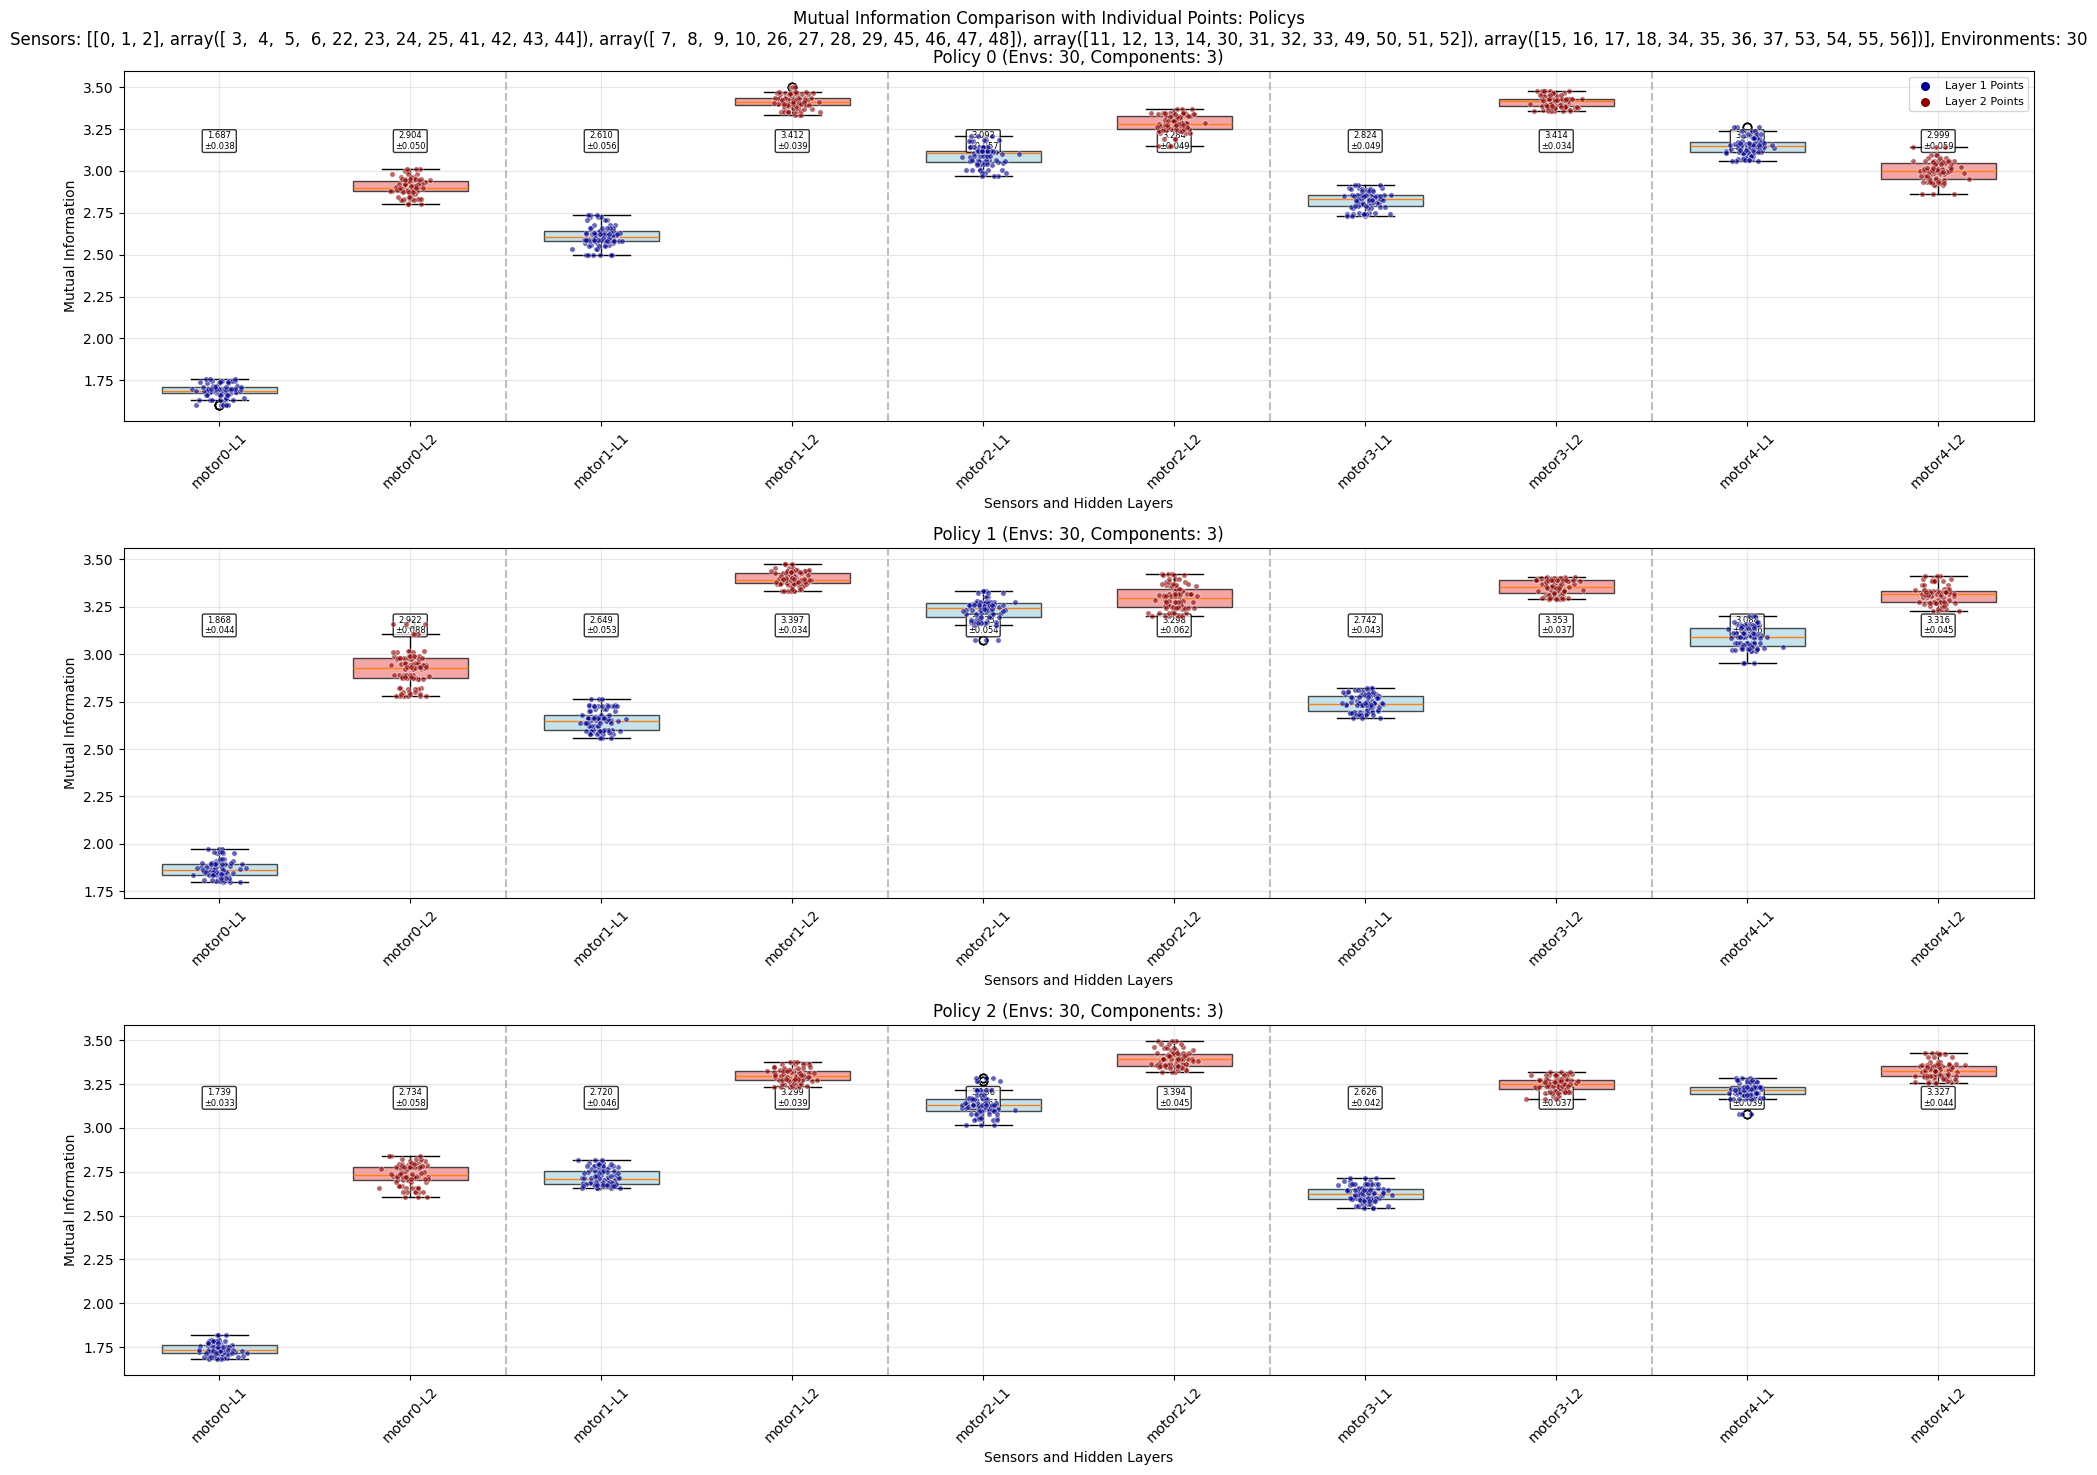

Analysis complete! Compared 3 policies in case 'flat'

=== FLAT : Two-layer Rankings per Policy ===

Policy 0
  L1 top sensors:
     1. motor4        MI=3.14579
     2. motor2        MI=3.09225
     3. motor3        MI=2.82393
     4. motor1        MI=2.60974
     5. motor0        MI=1.68713
  L2 top sensors:
     1. motor3        MI=3.41389
     2. motor1        MI=3.41220
     3. motor2        MI=3.28442
     4. motor4        MI=2.99928
     5. motor0        MI=2.90374

Policy 1
  L1 top sensors:
     1. motor2        MI=3.23475
     2. motor4        MI=3.08833
     3. motor3        MI=2.74177
     4. motor1        MI=2.64931
     5. motor0        MI=1.86838
  L2 top sensors:
     1. motor1        MI=3.39664
     2. motor3        MI=3.35305
     3. motor4        MI=3.31555
     4. motor2        MI=3.29842
     5. motor0        MI=2.92180

Policy 2
  L1 top sensors:
     1. motor4        MI=3.21252
     2. motor2        MI=3.13576
     3. motor1        MI=2.71959
     4. motor3       

In [7]:
print("\n=== Creating Heatmap for Policy Comparison ===")
label = ["motor0","motor1","motor2","motor3","motor4",]
layer_names = ["L1" , "L2"]
policies = [0,1,2]
# --- flat ---
res_flat, data_flat, _ = run_policy_comparison(
    selected_dataset, target_case="flat",
    policies_to_compare=policies, num_env=30,
    show_scatter=True, group=group, mode="ksg", label=label
)
rank_flat = rank_two_layers_per_policy(data_flat, label, policies, top_k=None)  # full sorted lists
print_two_layer_rankings(rank_flat, "flat", top_k_preview=5)

# If you want DataFrames separated by layer:
df_flat_L1 = rankings_layer_to_dataframe(rank_flat, "flat", layer="L1")
df_flat_L2 = rankings_layer_to_dataframe(rank_flat, "flat", layer="L2")